In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('Enaho01-2025-100.csv', 
                encoding='latin-1', 
                sep=';',
                skipinitialspace=True, 
                low_memory=False)
display(df.shape)
display(df.head())

(44599, 336)

,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,UBIGEO,DOMINIO,ESTRATO,PERIODO,TIPENC,...,NBI4,NBI5,FACTOR07,CODCCPP,NOMCCPP,NCONGLOME,SUB_CONGLOME,LONGITUD,LATITUD,ALTITUD
0,2025,1,15009,12,11,10101,4,4,2,1,...,0.0,0.0,"87,2856903076172",1,CIUDAD CHACHAPOYAS,7098,0,"-77,869230754","-6,234386829","2350,55706301"
1,2025,1,15009,25,11,10101,4,4,2,1,...,0.0,0.0,"87,2856903076172",1,CIUDAD CHACHAPOYAS,7098,0,"-77,869230754","-6,234386829","2350,55706301"
2,2025,1,15009,36,11,10101,4,4,2,1,...,NaN,NaN,"87,2856903076172",1,CIUDAD CHACHAPOYAS,7098,0,"-77,869230754","-6,234386829","2350,55706301"
3,2025,1,15009,49,11,10101,4,4,2,1,...,0.0,0.0,"87,2856903076172",1,CIUDAD CHACHAPOYAS,7098,0,"-77,869230754","-6,234386829","2350,55706301"
4,2025,1,15009,61,11,10101,4,4,2,1,...,0.0,0.0,"87,2856903076172",1,CIUDAD CHACHAPOYAS,7098,0,"-77,869230754","-6,234386829","2350,55706301"


In [29]:
#FILTRAMOS LOS REGISROS

#Filtramos los registros completos (completaron la encuesta)
df = df[df['RESULT'].isin([1, 2])]

#Filtramos los registros pertenecientes a Lima y Callao (UBIGEO 15 y 07)
df['UBIGEO'] = df['UBIGEO'].astype(str).str.zfill(6)
df = df[df['UBIGEO'].str.startswith(('07', '15'))]


display(df.shape)
display(df.head())

(5589, 336)

,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,UBIGEO,DOMINIO,ESTRATO,PERIODO,TIPENC,...,NBI4,NBI5,FACTOR07,CODCCPP,NOMCCPP,NCONGLOME,SUB_CONGLOME,LONGITUD,LATITUD,ALTITUD
790,2025,1,16166,23,11,070104,8,1,4,1,...,0.0,0.0,"114,352256774902",1,URB BENJAMIN DOG,18530,0,"-77,116306518","-12,068178924","23,3398414958"
791,2025,1,16166,40,11,070104,8,1,4,1,...,0.0,0.0,"114,352256774902",1,URBANIZACION BENJAMIN DOIG LOSSIO,18530,0,"-77,116306518","-12,068178924","23,3398414958"
794,2025,1,16166,89,11,070104,8,1,4,1,...,0.0,0.0,"114,352256774902",1,URBANIZACION BENJAMIN DOING,18530,0,"-77,116306518","-12,068178924","23,3398414958"
797,2025,1,16166,127,11,070104,8,1,4,1,...,0.0,0.0,"114,352256774902",1,LA PERLA,18530,0,"-77,116306518","-12,068178924","23,3398414958"
798,2025,1,16166,142,11,070104,8,1,4,1,...,0.0,0.0,"114,352256774902",1,URBANIZACION BENJAMIN DOIG LOSSIO,18530,0,"-77,116306518","-12,068178924","23,3398414958"


In [30]:
#FILTRAMOS LAS COLUMNAS

colums_valid_names = {
    'CONGLOME' : 'conglomerado',
    'VIVIENDA' : 'vivienda',
    'HOGAR' : 'hogar', 
    'P103' : 'material_piso', 
    'P102' : 'material_pared_exterior',
    'P110' : 'fuente_agua', 
    'P111A' : 'conexion_bano', 
    'P113A' : 'combustible_cocina', 
    'P104' : 'total_habitaciones',
    'P104A' : 'total_dormitorios',
    'P105A' : 'tenencia_vivienda', 
    'P106A' : 'titulo_propiedad',
    'P106B' : 'registro_sunarp', 
    'NBI1' : 'vivienda_inadecuada',
    'NBI2' : 'vivienda_hacinamiento',
    'NBI3' : 'vivienda_sin_bano',
    'NBI4' : 'nino_sin_educacion',
    'NBI5' : 'dependencia_economica'
}

df = df[colums_valid_names.keys()]
df = df.rename(columns=colums_valid_names)
df.set_index(['conglomerado', 'vivienda', 'hogar'], inplace=True)

display(df.shape)
display(df.head(20))

(5589, 15)

material_piso  material_pared_exterior  \
conglomerado vivienda hogar                                           
16166        23       11               3.0                      1.0   
             40       11               3.0                      1.0   
             89       11               3.0                      1.0   
             127      11               5.0                      1.0   
             142      11               3.0                      1.0   
             153      11               1.0                      1.0   
16187        22       11               5.0                      1.0   
             47       12               5.0                      1.0   
                      22               NaN                      NaN   
             72       11               5.0                      1.0   
             95       11               3.0                      1.0   
             140      11               5.0                      1.0   
             160      11               5.0                      1.0   
16205        1        11               5.0                      1.0   
             9        11               5.0                      7.0   
             17       11               5.0                      9.0   
             27       11               5.0                      7.0   
             35       11               7.0                      7.0   
             47       11               5.0                      7.0   
16219        10       11               5.0                      7.0   

                             fuente_agua  conexion_bano  combustible_cocina  \
conglomerado vivienda hogar                                                   
16166        23       11             1.0            1.0                 NaN   
             40       11             1.0            1.0                 2.0   
             89       11             1.0            1.0                 3.0   
             127      11             1.0            1.0                 2.0   
             142      11             1.0            1.0                 2.0   
             153      11             1.0            1.0                 3.0   
16187        22       11             1.0            1.0                 2.0   
             47       12             1.0            1.0                 3.0   
                      22             1.0            1.0                 3.0   
             72       11             1.0            1.0                 3.0   
             95       11             1.0            1.0                 3.0   
             140      11             1.0            1.0                 3.0   
             160      11             1.0            1.0                 3.0   
16205        1        11             2.0            2.0                 3.0   
             9        11             1.0            1.0                 3.0   
             17       11             1.0            1.0                 3.0   
             27       11             1.0            1.0                 3.0   
             35       11             1.0            1.0                 3.0   
             47       11             1.0            1.0                 3.0   
16219        10       11             4.0            7.0                 2.0   

                             total_habitaciones  total_dormitorios  \
conglomerado vivienda hogar                                          
16166        23       11                    2.0                1.0   
             40       11                    6.0                4.0   
             89       11                    4.0                3.0   
             127      11                    2.0                1.0   
             142      11                    3.0                2.0   
             153      11                    7.0                4.0   
16187        22       11                    3.0                2.0   
             47       12                    7.0                4.0   
                      22   

In [31]:
# VALORES DE LOS DATOS

colums_valid_names = {
    'conglomerado': None,
    'vivienda': None,
    'hogar': None,
    
    # P103
    'material_piso': {
        1: 'parquet',
        2: 'vinilico',
        3: 'loseta',
        4: 'madera',
        5: 'cemento',
        6: 'tierra',
        7: 'otro'
    },
    
    # P102
    'material_pared_exterior': {
        1: 'ladrillo',
        2: 'piedra_cemento',
        3: 'adobe',
        4: 'tapia',
        5: 'quincha',
        6: 'piedra_barro',
        7: 'madera',
        8: 'triplay_calamina',
        9: 'otro'
    },
    
    # P110
    'fuente_agua': {
        1: 'red_interior',
        2: 'red_exterior',
        3: 'pilon',
        4: 'cisterna',
        5: 'pozo',
        6: 'manantial',
        7: 'otro',
        8: 'rio_laguna'
    },
    
    # P111A
    'conexion_bano': {
        1: 'desague_interior',
        2: 'desague_exterior',
        3: 'letrina',
        4: 'pozo_septico',
        5: 'pozo_ciego',
        6: 'rio_canal',
        7: 'otro',
        9: 'campo_abierto'
    },
    
    # P113A
    'combustible_cocina': {
        1: 'electricidad',
        2: 'gas_glp',
        3: 'gas_natural',
        5: 'carbon',
        6: 'lena',
        7: 'otro',
        8: 'no_cocina'
    },
    
    'total_habitaciones': None,
    'total_dormitorios': None,
    
    # P105A
    'tenencia_vivienda': {
        1: 'alquilada',
        2: 'propia_pagada',
        3: 'propia_invasion',
        4: 'propia_plazos',
        5: 'cedida_trabajo',
        6: 'cedida_otro',
        7: 'otro'
    },
    
    # P106A
    'titulo_propiedad': {
        1: 'si',
        2: 'no',
        3: 'en_tramite'
    },
    
    # P106B
    'registro_sunarp': {
        1: 'si',
        2: 'no'
    },
    
    # NBI1 a NBI5 (0: adecuado / no padece, 1: carencia / insatisfecha)
    'vivienda_inadecuada': {
        0: 'adecuada',
        1: 'inadecuada'
    },
    'vivienda_hacinamiento': {
        0: 'no_hacinada',
        1: 'hacinada'
    },
    'vivienda_sin_bano': {
        0: 'con_bano',
        1: 'sin_bano'
    },
    'nino_sin_educacion': {
        0: 'asiste',
        1: 'no_asiste'
    },
    'dependencia_economica': {
        0: 'baja_dependencia',
        1: 'alta_dependencia'
    }
}

for col, mapping in colums_valid_names.items():
    if mapping and col in df.columns:
        df[col] = df[col].map(mapping)

display(df.shape)
display(df.head(20))

(5589, 15)

material_piso material_pared_exterior  \
conglomerado vivienda hogar                                         
16166        23       11           loseta                ladrillo   
             40       11           loseta                ladrillo   
             89       11           loseta                ladrillo   
             127      11          cemento                ladrillo   
             142      11           loseta                ladrillo   
             153      11          parquet                ladrillo   
16187        22       11          cemento                ladrillo   
             47       12          cemento                ladrillo   
                      22              NaN                     NaN   
             72       11          cemento                ladrillo   
             95       11           loseta                ladrillo   
             140      11          cemento                ladrillo   
             160      11          cemento                ladrillo   
16205        1        11          cemento                ladrillo   
             9        11          cemento                  madera   
             17       11          cemento                    otro   
             27       11          cemento                  madera   
             35       11             otro                  madera   
             47       11          cemento                  madera   
16219        10       11          cemento                  madera   

                              fuente_agua     conexion_bano  \
conglomerado vivienda hogar                                   
16166        23       11     red_interior  desague_interior   
             40       11     red_interior  desague_interior   
             89       11     red_interior  desague_interior   
             127      11     red_interior  desague_interior   
             142      11     red_interior  desague_interior   
             153      11     red_interior  desague_interior   
16187        22       11     red_interior  desague_interior   
             47       12     red_interior  desague_interior   
                      22     red_interior  desague_interior   
             72       11     red_interior  desague_interior   
             95       11     red_interior  desague_interior   
             140      11     red_interior  desague_interior   
             160      11     red_interior  desague_interior   
16205        1        11     red_exterior  desague_exterior   
             9        11     red_interior  desague_interior   
             17       11     red_interior  desague_interior   
             27       11     red_interior  desague_interior   
             35       11     red_interior  desague_interior   
             47       11     red_interior  desague_interior   
16219        10       11         cisterna              otro   

                            combustible_cocina  total_habitaciones  \
conglomerado vivienda hogar                                          
16166        23       11                   NaN                 2.0   
             40       11               gas_glp                 6.0   
             89       11           gas_natural                 4.0   
             127      11               gas_glp                 2.0   
             142      11               gas_glp                 3.0   
             153      11           gas_natural                 7.0   
16187        22       11               gas_glp                 3.0   
             47       12           gas_natural                 7.0   
                      22           gas_natural                 NaN   
             72       11           gas_natural                 3.0   
             95       11           gas_natural                 3.0   
             140      11           gas_natural                 4.0   
             160      11           gas_natural                 4.0   
16205        1        11           gas_natural                 1.0   
  

In [32]:
display(df.isnull().sum())
display(df.isnull().mean()*100)

material_piso               120
material_pared_exterior     120
fuente_agua                   0
conexion_bano                 0
combustible_cocina           84
total_habitaciones          120
total_dormitorios           120
tenencia_vivienda             0
titulo_propiedad           1827
registro_sunarp            3196
vivienda_inadecuada           0
vivienda_hacinamiento         0
vivienda_sin_bano             0
nino_sin_educacion            0
dependencia_economica         0
dtype: int64

material_piso               2.147075
material_pared_exterior     2.147075
fuente_agua                 0.000000
conexion_bano               0.000000
combustible_cocina          1.502952
total_habitaciones          2.147075
total_dormitorios           2.147075
tenencia_vivienda           0.000000
titulo_propiedad           32.689211
registro_sunarp            57.183754
vivienda_inadecuada         0.000000
vivienda_hacinamiento       0.000000
vivienda_sin_bano           0.000000
nino_sin_educacion          0.000000
dependencia_economica       0.000000
dtype: float64

In [33]:
str_cols = df.select_dtypes(include=['str']).columns.tolist()
df[str_cols] = df[str_cols].astype('category')

df_numeric = df.select_dtypes(include=np.number)
df_category = df.select_dtypes(include='category')

In [34]:
display(df_numeric.describe())
display(df_category.describe())

,total_habitaciones,total_dormitorios
count,5469.000000,5469.000000
mean,3.458036,2.232949
std,1.536892,1.162951
min,1.000000,0.000000
25%,2.000000,1.000000
50%,3.000000,2.000000
75%,4.000000,3.000000
max,12.000000,9.000000


,material_piso,material_pared_exterior,fuente_agua,conexion_bano,combustible_cocina,tenencia_vivienda,titulo_propiedad,registro_sunarp,vivienda_inadecuada,vivienda_hacinamiento,vivienda_sin_bano,nino_sin_educacion,dependencia_economica
count,5469,5469,5589,5589,5505,5589,3762,2393,5589,5589,5589,5589,5589
unique,7,9,8,8,6,7,3,2,2,2,2,2,2
top,cemento,ladrillo,red_interior,desague_interior,gas_glp,propia_pagada,si,si,adecuada,no_hacinada,con_bano,asiste,baja_dependencia
freq,2567,4214,4887,4672,3148,3373,2395,2171,5368,5442,5406,5571,5579


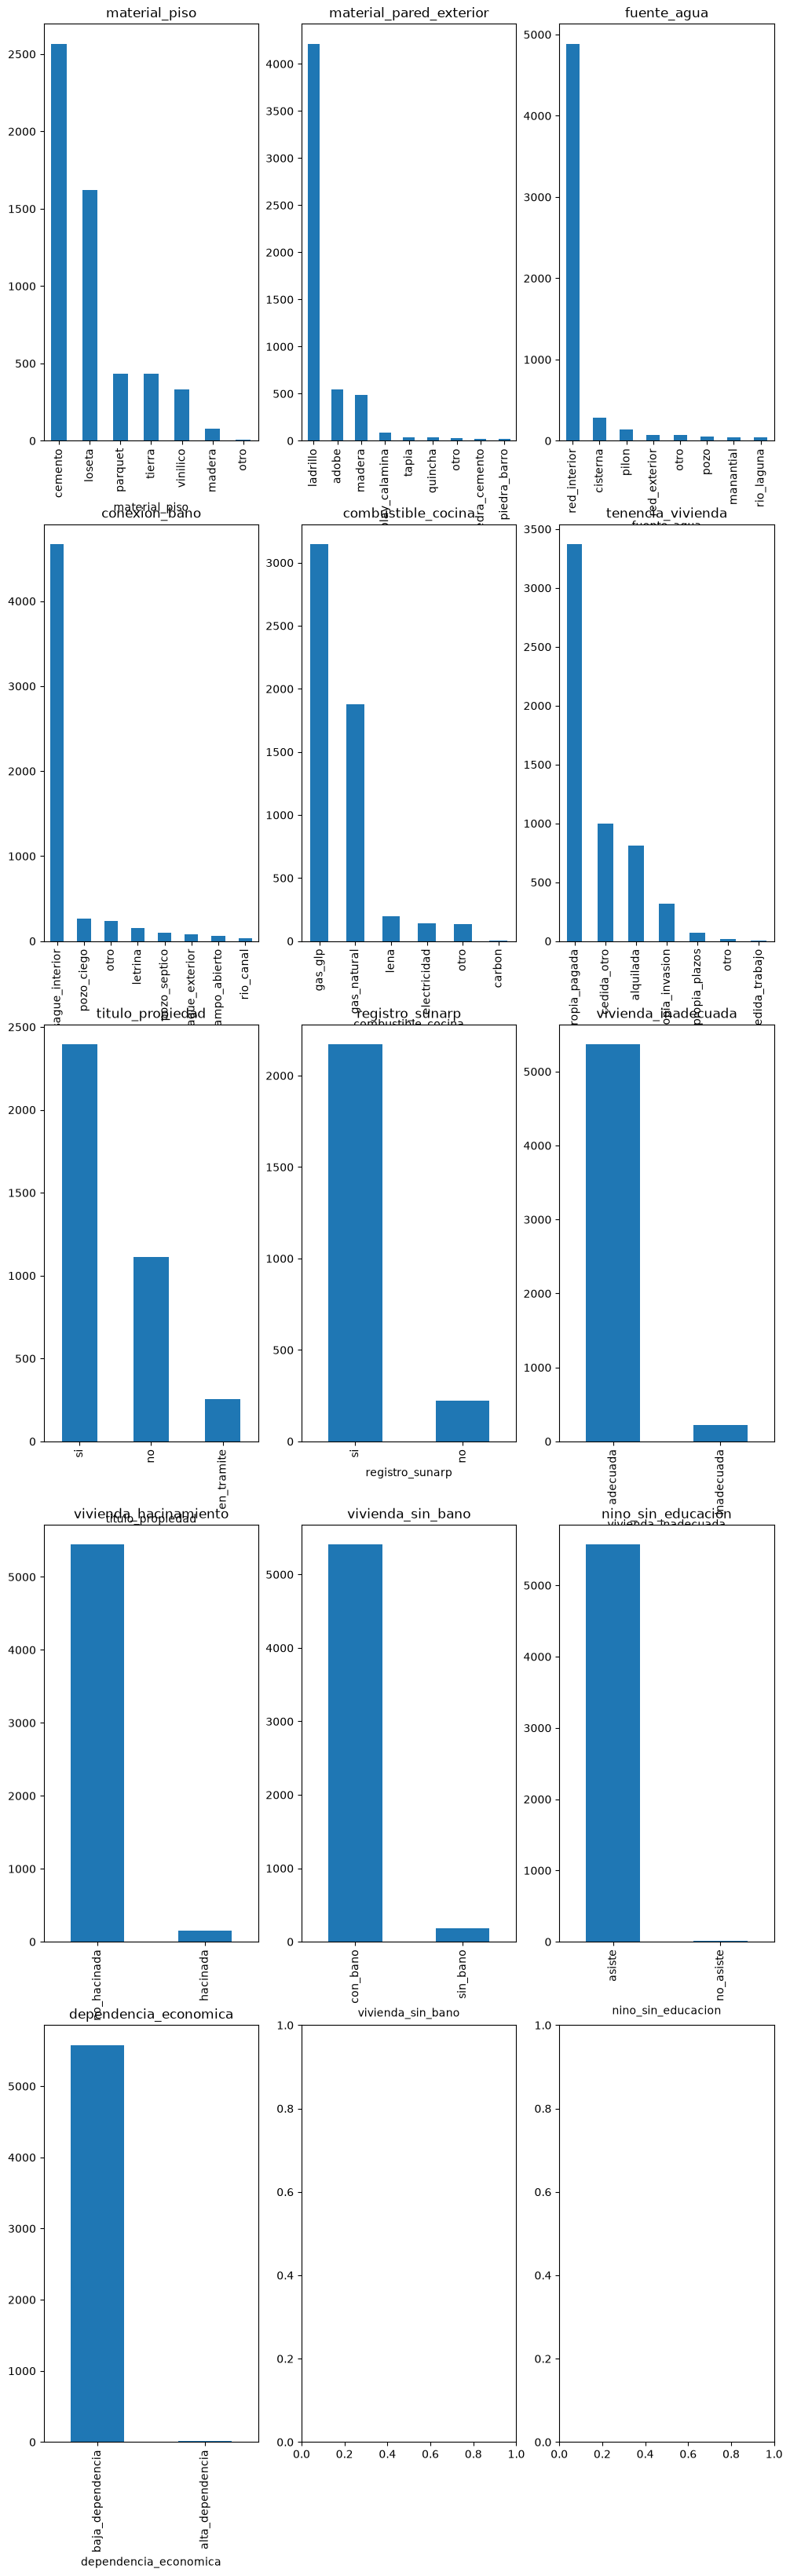

In [35]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(12, 40))
axes = axes.flatten()
for i, col in enumerate(df.select_dtypes(include='category').columns):
    df[col].value_counts().plot(kind='bar', ax=axes[i], title=col)

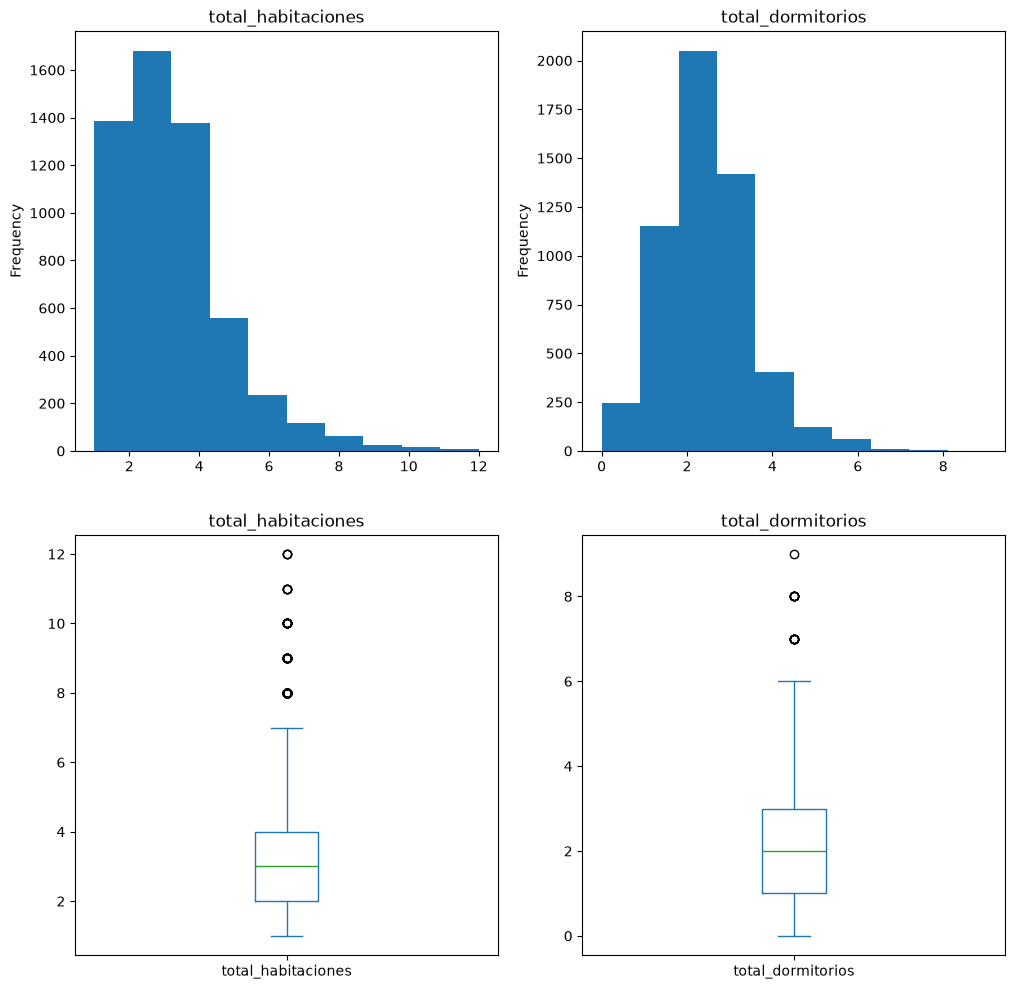

In [36]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axes = axes.flatten()
for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    df[col].plot(kind='hist', ax=axes[i], title=col)
    df[col].plot(kind='box', ax=axes[i+2], title=col)
    

In [37]:
df[df.select_dtypes(include='category').columns].value_counts()

material_piso  material_pared_exterior  fuente_agua   conexion_bano     combustible_cocina  tenencia_vivienda  titulo_propiedad  registro_sunarp  vivienda_inadecuada  vivienda_hacinamiento  vivienda_sin_bano  nino_sin_educacion  dependencia_economica
loseta         ladrillo                 red_interior  desague_interior  gas_natural         propia_pagada      si                si               adecuada             no_hacinada            con_bano           asiste              baja_dependencia         334
                                                                        gas_glp             propia_pagada      si                si               adecuada             no_hacinada            con_bano           asiste              baja_dependencia         316
cemento        ladrillo                 red_interior  desague_interior  gas_natural         propia_pagada      si                si               adecuada             no_hacinada            con_bano           asiste              baja

In [38]:
df.to_csv('Enaho01-2025-100_cleaned.csv')